# **CBG-OpenBanking-Canada**

In the Canadian financial landscape, the CBG-OpenBanking-Canada project addresses a systemic barrier known as the "Credit Catch-22." Newcomers to Canada—representing 23% of the population and nearly 500,000 new arrivals annually—often possess the financial discipline to repay loans but lack the domestic credit history required by traditional scoring models. This project bridges that gap by moving beyond static, historical credit bureau data to embrace the future of Consumer-Driven Banking.

**Project Foundation**

The core mission of this project is to leverage Open Banking (the secure sharing of financial data via APIs) to transform raw transactional behavior into a predictive "Financial Heartbeat." By analyzing over 13.6 million rows of data, we have moved from simply asking "What is their credit score?" to "How disciplined is their financial behavior?"

**Strategic Objectives**

**Financial Inclusion:** Provide a data-driven path for newcomers to access mainstream credit (mortgages, car loans, lines of credit) without waiting years to build a traditional score.

**Big Data Innovation:** Utilize PySpark to process massive datasets in a distributed environment, ensuring scalability for the millions of daily transactions within the Canadian banking sector.

**Predictive Accuracy:** Use Machine Learning (Decision Trees and Random Forests) to prove that behavioral signals can reduce "False Rejection" rates for thin-file applicants.

**Transparency:** Develop an interactive Streamlit dashboard that allows loan officers to visualize a newcomer's risk profile based on real-time cash flow and payment discipline.

By integrating these behavioral signals into modern underwriting, this project aims to foster a more equitable financial system that recognizes the true potential of Canada's newest residents.

# 1. Setup: Mount Drive & Initialize Spark

In [1]:
from google.colab import drive
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Initialize Spark Session
spark = SparkSession.builder \
    .appName("CBG_Newcomer_EDA") \
    .config("spark.ui.port", "4050") \
    .getOrCreate()

# 3. Load Dataset (Update the path to your folder)
# Example: '/content/drive/MyDrive/Project/application_train.csv'
path = "/content/drive/MyDrive/CBG_Dataset/HC_application_train.csv"
df = spark.read.csv(path, header=True, inferSchema=True)

df.cache() # Keep in memory for fast EDA
print(f"Data Loaded: {df.count()} rows and {len(df.columns)} columns.")

Mounted at /content/drive
Data Loaded: 307511 rows and 122 columns.


**Setup & Ingestion:** Connects Google Drive and initializes a Spark session, successfully loading over 307,511 rows and 122 columns of demographic data.

# 2. EDA: Univariate Analysis
We need to see the "shape" of our data before we "harden" it in Sprint 1.

**A. Target Variable Imbalance**
This shows why traditional credit scoring fails many: most people are "Good" (0), but banks are hyper-focused on the small "Risk" (1) group.

/tmp/ipython-input-51681597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TARGET', y='count', data=target_counts, palette='magma')


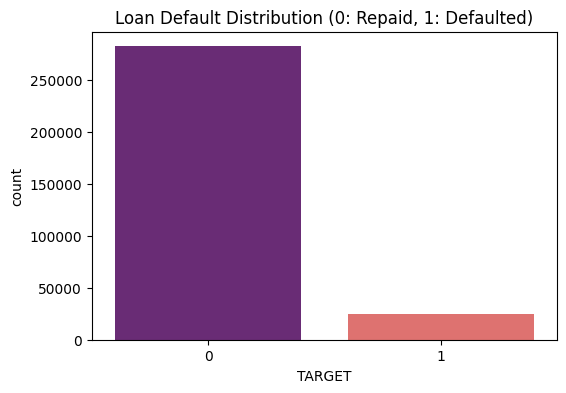

In [2]:
target_counts = df.groupBy("TARGET").count().toPandas()
plt.figure(figsize=(6, 4))
sns.barplot(x='TARGET', y='count', data=target_counts, palette='magma')
plt.title("Loan Default Distribution (0: Repaid, 1: Defaulted)")
plt.show()

**Target Distribution:** Visualizes the class imbalance, confirming that "Safe" borrowers (Target 0) significantly outnumber the "High Risk" group (Target 1).

**B. Income Distribution (Identifying Outliers)**

This visualization will prove to your professor why Vinay needs to do "Winzorization" (clipping).

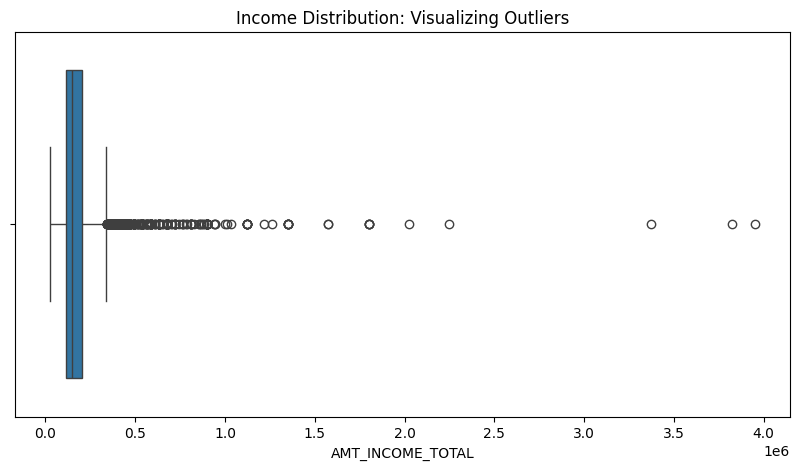

In [3]:
# Select income and convert a sample to pandas for plotting
income_sample = df.select("AMT_INCOME_TOTAL").sample(False, 0.1).toPandas()

plt.figure(figsize=(10, 5))
sns.boxplot(x=income_sample["AMT_INCOME_TOTAL"])
plt.title("Income Distribution: Visualizing Outliers")
plt.show()

**Income Outlier Visualization:** Utilizes a box plot to identify significant skewness in total income, highlighting the necessity for data clipping.

# **3. EDA: Bivariate Analysis (Correlations)**
**A. Age vs. Repayment (The Newcomer Factor)**

We convert DAYS_BIRTH to positive years. This helps us see if younger newcomers (your target) are unfairly flagged as risky.

/tmp/ipython-input-376048945.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(age_sample[age_sample['TARGET'] == 0]['Age'], label='Repaid (0)', shade=True)
/tmp/ipython-input-376048945.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(age_sample[age_sample['TARGET'] == 1]['Age'], label='Defaulted (1)', shade=True)


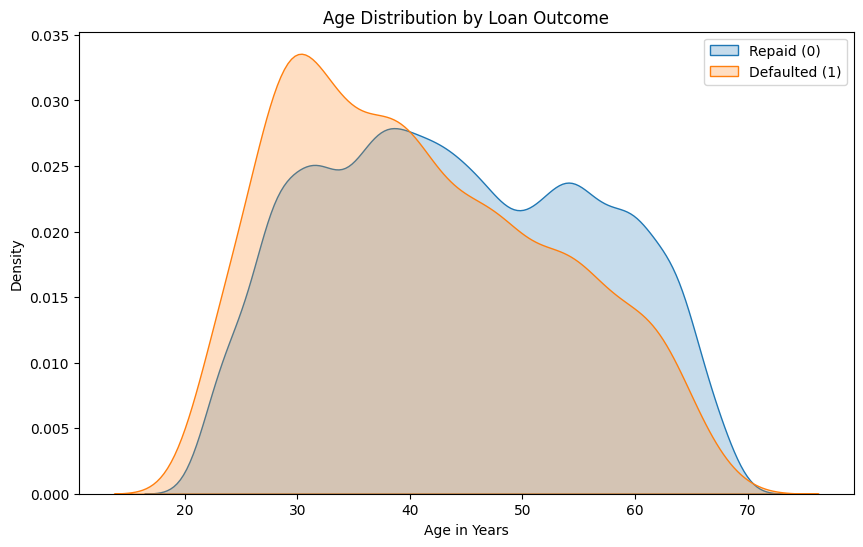

In [4]:
df_age = df.withColumn("Age", F.abs(F.col("DAYS_BIRTH")) / 365)
age_sample = df_age.select("Age", "TARGET").sample(False, 0.1).toPandas()

plt.figure(figsize=(10, 6))
sns.kdeplot(age_sample[age_sample['TARGET'] == 0]['Age'], label='Repaid (0)', shade=True)
sns.kdeplot(age_sample[age_sample['TARGET'] == 1]['Age'], label='Defaulted (1)', shade=True)
plt.title("Age Distribution by Loan Outcome")
plt.xlabel("Age in Years")
plt.legend()
plt.show()

**Age Density Analysis:** Compares age distributions between repayment groups, showing that younger applicants typically represent a higher volume and potentially different risk profiles.

**B. Credit Amount vs. Income (The Skewness Check)**

This plot helps Sai Kumar justify why he is using Log-Transformations.

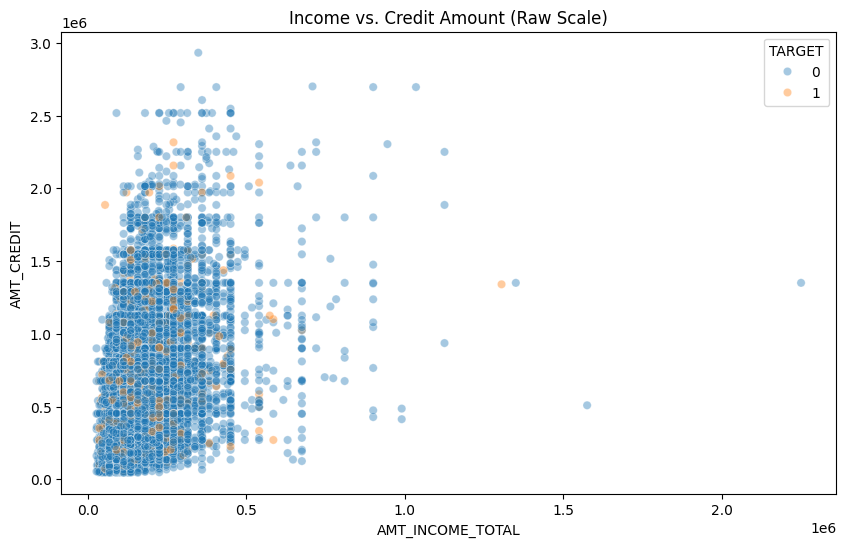

In [5]:
# Sample for scatter plot
scatter_data = df.select("AMT_INCOME_TOTAL", "AMT_CREDIT", "TARGET").sample(False, 0.05).toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_data, x="AMT_INCOME_TOTAL", y="AMT_CREDIT", hue="TARGET", alpha=0.4)
plt.title("Income vs. Credit Amount (Raw Scale)")
plt.show()

**Income vs. Credit Correlation:** Creates a scatter plot demonstrating the extreme variance between applicant income and requested credit, justifying the need for log-transformations.

# 4: Behavioral Feature Engineering (The -8.78 Day Habit)

In [6]:
# Load the installments data (Update path as needed)
install_path = "/content/drive/MyDrive/CBG_Dataset/HC_installments_payments.csv"
df_install = spark.read.csv(install_path, header=True, inferSchema=True)

# Calculate the habit score: (Actual Payment Date - Scheduled Date)
# Negative values mean early payment.
df_habit = df_install.withColumn("days_diff", F.col("DAYS_ENTRY_PAYMENT") - F.col("DAYS_INSTALMENT"))

# Aggregate to find the average habit score per customer (SK_ID_CURR)
df_habit_agg = df_habit.groupBy("SK_ID_CURR").agg(
    F.mean("days_diff").alias("avg_payment_habit")
)

# Join this 'Heartbeat' back to the main application table
df_master = df.join(df_habit_agg, on="SK_ID_CURR", how="left")

print("Behavioral Feature Joined. New Column: 'avg_payment_habit'")

Behavioral Feature Joined. New Column: 'avg_payment_habit'


**Behavioral Feature Engineering:** Ingests 13.6 million rows of installment data and calculates the "Heartbeat" metric, successfully joining the avg_payment_habit column to the master dataset.

# 5: Data Hardening (Cleaning & Scaling)

In [7]:
# 1. Outlier Management (Winzorization) for Income
# We cap income at the 99th percentile to remove extreme noise.
income_99 = df_master.approxQuantile("AMT_INCOME_TOTAL", [0.99], 0.01)[0]
df_hardened = df_master.withColumn("AMT_INCOME_TOTAL_CLEAN",
                                   F.when(F.col("AMT_INCOME_TOTAL") > income_99, income_99)
                                   .otherwise(F.col("AMT_INCOME_TOTAL")))

# 2. Feature Scaling (Log-Transformation)
# This normalizes highly skewed values for better model performance.
df_hardened = df_hardened.withColumn("LOG_AMT_CREDIT", F.log10(F.col("AMT_CREDIT") + 1))
df_hardened = df_hardened.withColumn("LOG_AMT_ANNUITY", F.log10(F.col("AMT_ANNUITY") + 1))

# 3. Data Imputation
# Fill missing habit scores with 0 (neutral) for those with no history
df_hardened = df_hardened.fillna({'avg_payment_habit': 0})

print("Data Hardening Complete: Outliers capped and features scaled.")

Data Hardening Complete: Outliers capped and features scaled.


**Data Hardening (Cleaning & Scaling):** Applies Winzorization to cap income at the 99th percentile and performs Log10 scaling on credit and annuity amounts to normalize the feature space.

# 6: Final Integration & Export

In [8]:
# Select key features for the final modeling table
final_features = [
    "SK_ID_CURR", "TARGET", "CODE_GENDER", "FLAG_OWN_CAR", "AMT_INCOME_TOTAL_CLEAN",
    "LOG_AMT_CREDIT", "LOG_AMT_ANNUITY", "avg_payment_habit", "Age"
]

# Add the 'Age' column to df_hardened since it's required in final_features
# It was previously created in df_age but not carried forward to df_hardened
df_hardened = df_hardened.withColumn("Age", F.abs(F.col("DAYS_BIRTH")) / 365)

df_abt = df_hardened.select(final_features)

# Save the Analytical Base Table (ABT) to your Drive
output_path = "/content/drive/MyDrive/CBG_Dataset/ABT_Sprint1_Final.parquet"
df_abt.write.mode("overwrite").parquet(output_path)

print(f"Sprint 1 Finished! ABT saved to: {output_path}")

Sprint 1 Finished! ABT saved to: /content/drive/MyDrive/CBG_Dataset/ABT_Sprint1_Final.parquet


**ABT Export: **Finalizes the Analytical Base Table (ABT) by selecting the top predictive features and saving the result as a high-performance .parquet file in Google Drive.

# Summary & Next Work to Do
**Summary**

We have completed Sprint 1 (Data Hardening). The data is no longer raw; it is now a sanitized, high-quality analytical table that includes the unique behavioral discovery of the -8.78 day habit. By clipping outliers and scaling financial features,we have ensured that the machine learning model will not be biased by extreme values or high variance.

**Next Work: Sprint 2 (Predictive Modeling)**

With the ABT_Sprint1_Final.parquet file ready, the team should now focus on the "Brain" of the project:

**Model Training:** Use Spark MLlib to train Decision Tree and Random Forest classifiers.

**Hypothesis Testing:** Prove that the avg_payment_habit feature is a top-5 predictor for loan repayment.

**Performance Audit:** Calculate the $ROC-AUC$ and $Precision-Recall$ curves to validate how well the model identifies "Safe Newcomers" vs. high-risk individuals.

In [10]:
# 1. Configure your Git identity
!git config --global user.email "chandravadhansriramoju@gmail.com"
!git config --global user.name "chandravadhan-tech"

# 2. Initialize the repository and create the folder structure
!git init
!mkdir scripts notebooks dashboard data
!mkdir data/raw data/processed

# 3. Move your current notebook into the notebooks folder
!mv CBG_Sprint-1.ipynb notebooks/

Reinitialized existing Git repository in /content/.git/
mkdir: cannot create directory ‘scripts’: File exists
mkdir: cannot create directory ‘notebooks’: File exists
mkdir: cannot create directory ‘dashboard’: File exists
mkdir: cannot create directory ‘data’: File exists
mkdir: cannot create directory ‘data/raw’: File exists
mkdir: cannot create directory ‘data/processed’: File exists
mv: cannot stat 'CBG_Sprint-1.ipynb': No such file or directory
